In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Gao2023 import Gao2023

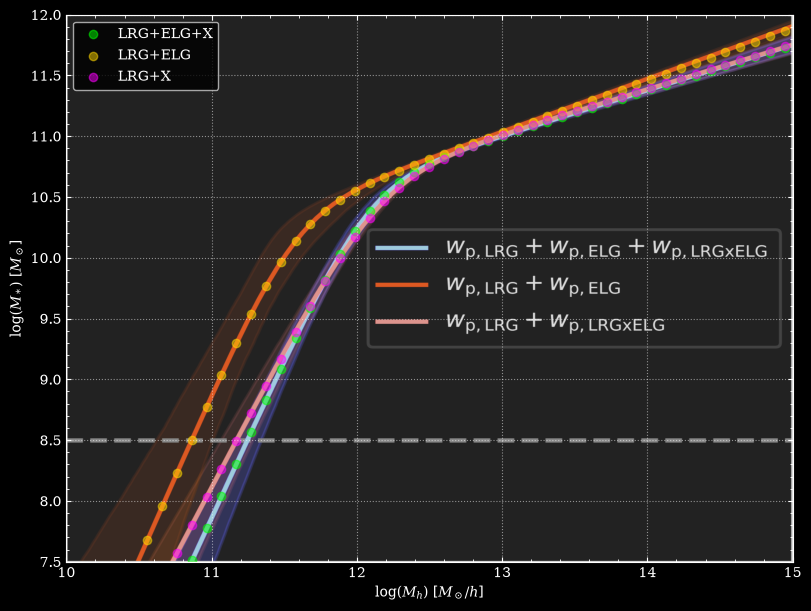

In [2]:
importlib.reload(Gao2023)
fig, ax = Gao2023.Fig7a().full()

from Models import SHMRs
importlib.reload(SHMRs)

logMh = np.linspace(10, 15, 50)
logMhh = np.log10(10**logMh/SHMRs.Gao2023().h)
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Psat'}).SHMR(logMh)(), alpha=0.5, c='lime', label='LRG+ELG+X')
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Auto'}).SHMR(logMh)(), alpha=0.5, c='gold', label='LRG+ELG')
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Cross'}).SHMR(logMh)(), alpha=0.5, c='magenta', label='LRG+X')

ax.legend()
plt.show()

AttributeError: 'Gao2023' object has no attribute 'make_zdists'

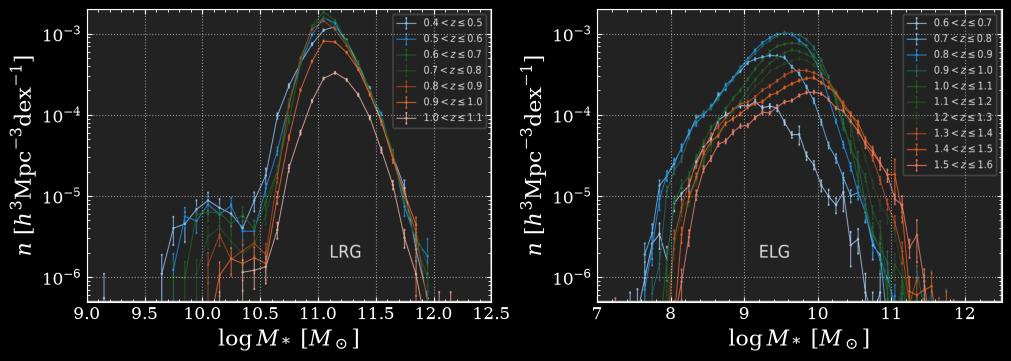

In [2]:
importlib.reload(Gao2023)

fig, axs = Gao2023.Fig2().full()

from Models import TargetData

G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[0].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

G23 = TargetData.Gao2023(sample='ELG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[1].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

axs[0].legend(fontsize=10, loc='upper left'); axs[1].legend(fontsize=10, loc='upper left')
plt.show()